<h2 id="%EC%9B%90-%ED%95%AB-%EC%9D%B8%EC%BD%94%EB%94%A9(One-Hot-Encoding)%EA%B3%BC-%EB%8B%A8%EC%96%B4-%EC%9E%84%EB%B2%A0%EB%94%A9">원-핫 인코딩(One-Hot Encoding)과 단어 임베딩¶</h2>
범주형 데이터를 수치형으로 변환하는 방법 중 하나인 원-핫 인코딩과 단어 임베딩

<h2 id="%EB%B2%94%EC%A3%BC%ED%98%95-%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%9D%98-%EC%88%AB%EC%9E%90-%EB%B3%80%ED%99%98%EA%B3%BC-One-Hot-Encoding%EC%9D%98-%EC%A4%91%EC%9A%94%EC%84%B1">범주형 데이터의 숫자 변환과 One-Hot Encoding의 중요성¶</h2>
범주형 데이터를 기계학습 모델에 적용할 때 단순히 숫자로 변환하면 발생하는 문제점과 해결방안

<h2 id="%EB%8B%A8%EC%88%9C-%EC%88%AB%EC%9E%90-%EB%B3%80%ED%99%98%EC%9D%98-%EB%AC%B8%EC%A0%9C%EC%A0%90">단순 숫자 변환의 문제점¶</h2><p>예를 들어, '성별' 데이터를 다음과 같이 변환한다고 가정해 보면은 여자(2)가 남자(1)보다 '더 크다'라는 잘못된 수학적 관계가 형성</p>
<p>숫자의 크기가 특성의 중요도나 우열을 의미하지 않음에도 모델이 그렇게 해석할 있다.</p>
<p>이러한 문제를 해결하기 위해 One-Hot Encoding을 사용</p>
    * 성별 데이터의 One-Hot Encoding
    남자 = [1, 0]  # [남자여부, 여자여부]
    여자 = [0, 1]  # [남자여부, 여자여부]

In [1]:
import pandas as pd
import numpy as np
import warnings as wr
wr.filterwarnings(action='ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# 이미지를 읽어와서 numpy로 변환 하기 위한 라이브러리
import matplotlib.image as mpimg
import os
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
plt.rcParams['font.family'] ="NanumGothic"
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 단어 임베딩이란 작업  => 단어를 컴퓨터가 이해 할  수 있는 수치로 변경해주는 작업
# "사과"-0,"배"-1,"고구마"-2
x = [0,1,2]
z = np.max(x) + 1
print(z)

3


In [3]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [4]:
x = np.array([0,1,2])
z = np.zeros((3,3))
print(z)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [5]:
np.arange(3)

array([0, 1, 2])

In [6]:
z[np.arange(3),x] = 1
z

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [7]:
fruit = {'사과':0,'배':1,'고구마':2,'감자':3,'오렌지':4,'키위':5}
fruit

{'사과': 0, '배': 1, '고구마': 2, '감자': 3, '오렌지': 4, '키위': 5}

In [8]:
#연습문제) 위의 딕셔너리는 각 단어의 각 토근에 대해서 고유한 인덱스를 부여 했다면
# 각 단어를 입력하면 이게 해당 토큰에 대한 원핫 인코딩을 출력하는 함수를 만드시오.
#예) myonehot("고구마",fruit)  => "고구마:"[0 0 1 ]
def myonehot(word,w2idx):
    #print(f"fruit의 키값으로 값 : {w2idx[word]}")
    print(len(w2idx))
    #print(np.zeros(len(w2idx)))
    one_hot_v = np.zeros(len(w2idx))
    #키값에 해당되는 인덱스를 저장 
    index = w2idx[word]
    #print(index)
    # one_hot_v 즉 => [0. 0. 0. 0.] 여기서 뭘 한다 index를 1로 만들면 된다.
    one_hot_v[index] = 1
    return one_hot_v

In [9]:
print(myonehot('고구마',fruit))
print(myonehot('배',fruit))
print(myonehot('오렌지',fruit))
print(myonehot('키위',fruit))

6
[0. 0. 1. 0. 0. 0.]
6
[0. 1. 0. 0. 0. 0.]
6
[0. 0. 0. 0. 1. 0.]
6
[0. 0. 0. 0. 0. 1.]


In [10]:
np.eye(len(fruit))

array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]])

In [11]:
np.eye(len(fruit))[fruit['고구마']]

array([0., 0., 1., 0., 0., 0.])

In [12]:
def myone_hot2(word, w2idx):
    print(np.eye(len(w2idx))[w2idx[word]])
    return np.eye(len(w2idx))[w2idx[word]]
myone_hot2('고구마',fruit)

[0. 0. 1. 0. 0. 0.]


array([0., 0., 1., 0., 0., 0.])

<h2 id="%EC%8A%A4%EC%B9%BC%EB%9D%BC-%EC%97%B0%EC%82%B0">스칼라 연산¶</h2>
NumPy 배열에서는 기본적인 산술 연산자(+, -, *, /)

In [13]:
x = np.array([1,2,3])
y = np.array([4,5,6])
print(x+y)
print(x-y)
print(x*y)
print(x/y)

[5 7 9]
[-3 -3 -3]
[ 4 10 18]
[0.25 0.4  0.5 ]


<h2 id="%EB%B2%A1%ED%84%B0%EC%9D%98-%EB%82%B4%EC%A0%81">벡터의 내적¶</h2>
np.dot(x,y)
벡터의 내적 (Dot Product)

<p>$ a\ \cdot \ b=\ \sum _{i=1}^n\ ai\ bi^{ } $</p>
<p>$ a = [1,2,3] , b = [4,5,6] $</p>
<p>$ a\ \cdot \ b = 1 X 4 + 2 X 5 + 3 X 6 $</p>

In [14]:
x = np.array([1,2,3])
y = np.array([4,5,6])
print(f'벡터의 내적 : {np.dot(x,y)}')

벡터의 내적 : 32


<h2 id="np.full()">np.full()¶</h2>
<p>지정한 shape으로 특정값을 가지는 새로운 배열을 만들수 있다.</p>

<p>broadcasting 할때 자주 사용하는 함수이다. np.full(shape, fill_value)</p>

In [15]:
np.full((3,5),5)

array([[5, 5, 5, 5, 5],
       [5, 5, 5, 5, 5],
       [5, 5, 5, 5, 5]])

In [16]:
x = np.array([1,2,3,4])
y = np.array([5])
x.shape , y.shape
np.full(x.shape,y) , np.full(x.shape,y).shape

(array([5, 5, 5, 5]), (4,))

In [17]:
x = np.array([1,2,3,4])
y = np.array([5])
print(x*y)
#NumPy의 dot 함수는 내적(dot product)을 계산할 때 두 벡터의 크기가 동일해야 한다.
#print(np.dot(x,y))

[ 5 10 15 20]


In [18]:
# 벡터 x와 y의 크기를 맞추고 내적 계산
# 벡터 x와 y 정의
# x dot y = 1x5 + 2x5 + 3x5 + 4x5 = 50
y_expanded = np.full(x.shape,y)
x.shape,y_expanded.shape
my_dot = np.dot(x,y_expanded)
my_dot

np.int64(50)

In [19]:
seq = [
    np.array([1, 2, 3]),
    np.array([4, 5]),
    np.array([6, 7, 8, 9])
]
print(f"len(seq) => {len(seq)}")
max_length = max(len(s) for s in seq)
print(max_length)
padded = np.full((len(seq), max_length), 0)
print(padded)
print(padded[0,:len(seq)],seq[0])
for i, seq in enumerate(seq):
    padded[i, :len(seq)] = seq
    print(padded[i, :len(seq)])
print("결과")
print(padded)

len(seq) => 3
4
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
[0 0 0] [1 2 3]
[1 2 3]
[4 5]
[6 7 8 9]
결과
[[1 2 3 0]
 [4 5 0 0]
 [6 7 8 9]]


In [20]:
#<연습문제> NumPy를 사용하여 다음 시퀀스들을 패딩하는 함수를 구현하세요 (팀원 확정)
seq = [
    np.array([1, 2, 3]),
    np.array([4, 5]),
    np.array([6, 7, 8, 9])
]
seq

def pad_seq_numpy(seq, max_length=None, padding='post', pad_value=0):
    # 최대 길이가 없을 경우 경우, 가장 긴 시퀀스의 길이를 사용
    print(f"len(seq) => {len(seq)}")
    if max_length is None:
        max_length = max(len(s) for s in seq)
        print(max_length)
    padded = np.full((len(seq), max_length), pad_value)
    # #패드는 3x4 0 이 채워진다.
    # print(padded)
    # #print(padded[0, :len(seq)] , seq[0])
    # print('*'*30)
    # #거기에 값을 채운다.
    # for i , seq in enumerate(seq):
    #     padded[i, :len(seq)] = seq
    #     print(padded[i, :len(seq)])
    # return padded
    for i, seq in enumerate(seq):
        if padding == 'post':
           padded[i, :len(seq)] = seq
        else:
           print(i,seq)
           #a[start:end] 형태로 슬라이싱을 start와 end는 인덱스인데, 음수 인덱스는 뒤에 부터 
           #a[-3:] : 뒤에서 3개원소
           padded[i, -len(seq):] = seq
    return padded
result_post = pad_seq_numpy(seq, padding='post')
print("PostPadding")
print(result_post)
print('*'*30)
result_pre = pad_seq_numpy(seq,padding='pre')
print("PrePadding")
print(result_pre)

len(seq) => 3
4
PostPadding
[[1 2 3 0]
 [4 5 0 0]
 [6 7 8 9]]
******************************
len(seq) => 3
4
0 [1 2 3]
1 [4 5]
2 [6 7 8 9]
PrePadding
[[0 1 2 3]
 [0 0 4 5]
 [6 7 8 9]]


<h2 id="%EB%AC%B8%EC%A0%9C%ED%92%80%EC%9D%B42)">문제풀이2)¶</h2>
<p>문장을 가지고 임베딩하고 패딩하는 방법을 미리 보자.</p>

<p>자연어 처리할 때 여러가지 토큰을 하는 방법</p>

<p>Tokenizer, pad_sequences 모듈을 가지고 풀이한것을 적용</p>

In [21]:
# 사용사례, 자연어 처리 : 헤당 단어를 임베딩을 한 후에  생성된 0으로 채워진 배열을 만드는 이유
# => 단어의 실제 길이 만큼만 임베딩된 단어(수치)로 채우고, 나머지는 0으로 남겨 둬야 한다.
# 특정 단어를 패딩하는 작업이라고 한다아!!!!!!! *****
# 길이가 다른 단어의 길이를 같게 맞춰 주어서 병렬 처리를 할 수 있어서 효율적이기 때문에
# 매우 중요하고 자주 사용된다. 참고 0은 아무 의미가 없고 기계가 무시한다.
# 데이터의 특정 값을 채우고 길이를 맞추기 위해서(패딩) 0으로 채우는 이유는 데이터의 크기(shape) 조정 *****
# 숫자 0으로 채우는것을 제로 패딩(zero padding)

def pad_word(word,max_length):
    word_encoded = [ord(char) for char in word]
    padded_word = np.zeros(max_length,dtype=int)
    padded_word[:len(word_encoded)] = word_encoded
    return padded_word

In [22]:
word = "hello"
max_length = 18
padded_result = pad_word(word,max_length)
print(f"패딩된 단어 : {padded_result}")

패딩된 단어 : [104 101 108 108 111   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [23]:
word = "hello ict43"
max_length = 18
padded_result = pad_word(word,max_length)
print(f"패딩된 단어 :{padded_result}")

패딩된 단어 :[104 101 108 108 111  32 105  99 116  52  51   0   0   0   0   0   0   0]


In [1]:
import tensorflow as tf
tf.__version__

'2.21.0'

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
sequences = [
    "자연어 ICTPassword2",
    "ICTPassword2 딥러닝 자연어 처리",
    "ICTPassword2 딥러닝 자연어 처리는 재미있어요 자연어 정말 "
]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sequences)
#가장 기본 토큰 처리 모듈인 빈도 기반이다.
print(f"단어 인덱스 : {tokenizer.word_index}")
sequences = tokenizer.texts_to_sequences(sequences)
print(f'문장을 정수로 인코딩: {sequences}')
"""
자연어 => 1 (빈도가 가장 많은 순) 
"자연어 ICTPassword2", #[1,2]
"ICTPassword2 딥러닝 자연어 처리", [2,3,1,4]
"""
padded = pad_sequences(sequences,padding='post')
print(f'패딩된 결과: {padded}')
print('*'*30)
max_length = 8
padding_limit = pad_sequences(sequences,maxlen=max_length,padding='pre',truncating='pre')
print('길이 제한 및 앞쪽 패딩')
print(padding_limit)

단어 인덱스 : {'자연어': 1, 'ictpassword2': 2, '딥러닝': 3, '처리': 4, '처리는': 5, '재미있어요': 6, '정말': 7}
문장을 정수로 인코딩: [[1, 2], [2, 3, 1, 4], [2, 3, 1, 5, 6, 1, 7]]
패딩된 결과: [[1 2 0 0 0 0 0]
 [2 3 1 4 0 0 0]
 [2 3 1 5 6 1 7]]
******************************
길이 제한 및 앞쪽 패딩
[[0 0 0 0 0 0 1 2]
 [0 0 0 0 2 3 1 4]
 [0 2 3 1 5 6 1 7]]


In [4]:
# 우리가 만든 패딩 함수 적용 해보기

In [11]:
sequences = [
    "자연어 ICTPassword2",
    "ICTPassword2 딥러닝 자연어 처리",
    "ICTPassword2 딥러닝 자연어 처리는 재미있어요 자연어 정말 "
]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(sequences)

# 가장 기본 토큰 처리 모듈인 빈도 기반이다.
print(f"단어 인덱스 : {tokenizer.word_index}")

sequences = tokenizer.texts_to_sequences(sequences)
print(f"문장을 정수로 인코딩: {sequences}")

padded = pad_sequences(sequences, padding='post')
print(f'패딩된 결과: {padded}')

print('*' * 30)

max_length = 8
padding_limit = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='pre'
)

print('길이 제한 및 앞쪽 패딩')
print(padding_limit)

단어 인덱스 : {'자연어': 1, 'ictpassword2': 2, '딥러닝': 3, '처리': 4, '처리는': 5, '재미있어요': 6, '정말': 7}
문장을 정수로 인코딩: [[1, 2], [2, 3, 1, 4], [2, 3, 1, 5, 6, 1, 7]]
패딩된 결과: [[1 2 0 0 0 0 0]
 [2 3 1 4 0 0 0]
 [2 3 1 5 6 1 7]]
******************************
길이 제한 및 앞쪽 패딩
[[0 0 0 0 0 0 1 2]
 [0 0 0 0 2 3 1 4]
 [0 2 3 1 5 6 1 7]]


<h2 id="%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C">연습문제¶</h2>
A, B, C 세 회사의 주식은 각각 100만원, 80만원, 50만원이다. 이 주식을 각각 3주, 4주, 5주를 매수할 때 필요한 금액을 구하고자 한다.

<p>(1) 주식의 가격과 수량을 각각 p 벡터, n 벡터로 표시하고 넘파이로 코딩한다.</p>
<p>(2) 주식을 매수할 때 필요한 금액을 곱셈으로 표시하고 넘파이 연산으로 그 값을 계산한다.</p>
<p>값) 870 이 나온다.</p>

In [12]:
100 * 3 + 80 * 4 + 50 * 5

870

In [14]:
import numpy as np

In [15]:
p = np.array([100, 80, 50])
n = np.array([3, 4, 5])
total_cost = np.dot(p, n)
total_cost

np.int64(870)

<p>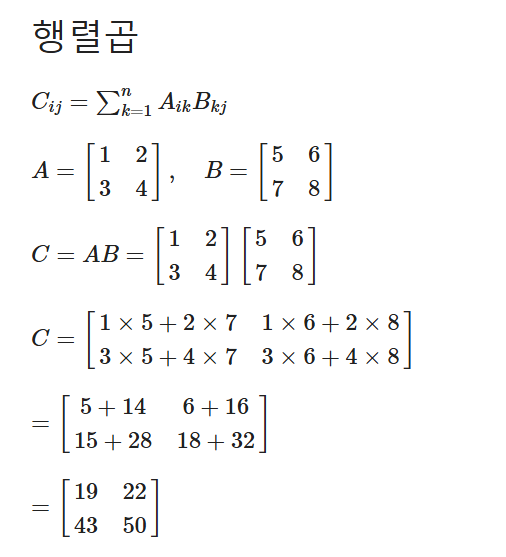</p>

<p>$ A=\begin{pmatrix}1&2\\3&4\end{pmatrix},\quad B=\begin{pmatrix}5&6\\7&8\end{pmatrix}\\ \Rightarrow \quad A+B=\begin{pmatrix}a_{11}+b_{11}&a_{12}+b_{12}\\a_{21}+b_{21}&a_{22}+b_{22}\end{pmatrix}\\ \Rightarrow \begin{pmatrix}19&22\\43&50\end{pmatrix} $</p>

In [16]:
a = np.array([[1,2],[3,4]])
b = np.array([[5,6],[7,8]])
print(a.shape,b.shape)

(2, 2) (2, 2)


In [17]:
# 2차원 x 2차원 - 벡터가 아닐 경우에는 즉 행렬의 곱은 dot을 사용하지 않는다.
# np.matmul(a,b) , a@b
np.dot(a,b) , np.matmul(a,b) , a@b

(array([[19, 22],
        [43, 50]]),
 array([[19, 22],
        [43, 50]]),
 array([[19, 22],
        [43, 50]]))

In [18]:
# 3차원일 때 비교해본다.
a_3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
b_2d = np.array([[[1, 2], [3, 4]]])
print(a_3d.ndim, b_2d.ndim)
print(a_3d.shape, b_2d.shape)
#여러분이 dot() ,matmul(),@ 각각 사용해서 출력 해보기

3 3
(2, 2, 2) (1, 2, 2)


In [19]:
# a @ b, np.matmul(a, b)와 결과 동일, dot 미사용 권장
dot_res = np.dot(a_3d,b_2d)
dot_res , dot_res.ndim , dot_res.shape

(array([[[[ 7, 10]],
 
         [[15, 22]]],
 
 
        [[[23, 34]],
 
         [[31, 46]]]]),
 4,
 (2, 2, 1, 2))

In [20]:
matmul_res = np.matmul(a_3d,b_2d)
matmul_res , matmul_res.ndim, matmul_res.shape

(array([[[ 7, 10],
         [15, 22]],
 
        [[23, 34],
         [31, 46]]]),
 3,
 (2, 2, 2))

In [21]:
matmul_res2 = a_3d @ b_2d
matmul_res2 , matmul_res2.ndim, matmul_res2.shape

(array([[[ 7, 10],
         [15, 22]],
 
        [[23, 34],
         [31, 46]]]),
 3,
 (2, 2, 2))

<h2 id="%EC%9C%A0%EC%82%AC%EB%8F%84">유사도¶</h2>
<p>벡터의 곱셈(내적)은 두 벡터 간의 유사도를 계산하는 데도 이용할 수 있다.</p>

<p>유사도(similarity)는 두 벡터가 닮은 정도를 정량적으로 나타낸 값으로 두 벡터가 비슷한 경우에는 유사도가 커지고 비슷하지 않는 경우에는 유사도가 작아진다.</p>

<p>내적을 이용하면 코사인 유사도(cosine similarity)라는 유사도를 계산할 수 있다.</p>

In [29]:
#!pip list | grep scikit-learn

In [33]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.2 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 15.4 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ----- ---------------------------------- 4.7/36.6 MB 31.8 MB/s eta 0:00:02
   -------- ------------------------------- 7.9/36.6 MB 19.5 MB/s eta 0:00:02
   ------------- -------------------------- 12.3/36.6 MB 20.3 MB/s eta 0:00:02
   ------------------- -------------------- 17.8/36.6 MB 20.8 MB/s eta 0:00:01
   ------------

In [34]:
#0 ~ 9까지의 손글씨 이미지를 제공해주는 데이터 셋
from sklearn.datasets import load_digits

In [35]:
digits = load_digits()

In [37]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------------------- ---------------- 5.5/9.3 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 26.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 20.0 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------------------------- ------ 6.0/7.2 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 22.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   --------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [38]:
import matplotlib.pyplot as plt

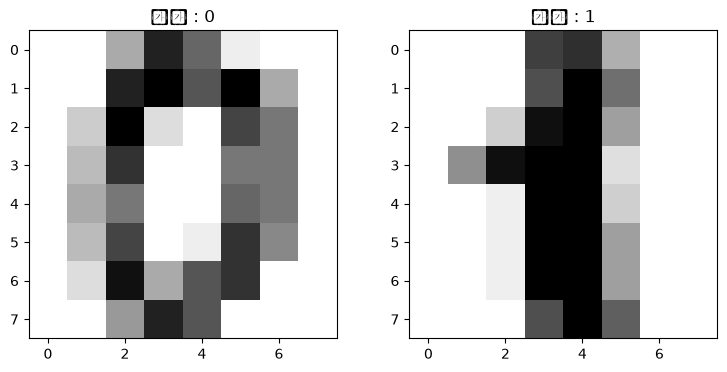

In [40]:
plt.figure(figsize=(9,4))
for i in range(2):
    plt.subplot(1,2,i+1)
    plt.imshow(digits.images[i],cmap=plt.cm.gray_r)
    plt.title(f'라벨 : {labels[i]}')
plt.show()

In [41]:
digits.images[0].shape , digits.images[1].shape

((8, 8), (8, 8))

<h2 id="%EC%BD%94%EC%82%AC%EC%9D%B8-%EC%9C%A0%EC%82%AC%EB%8F%84(Cosine-Similarity)">코사인 유사도(Cosine Similarity)¶</h2><p>$ \text{cosine similarity}(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\| \mathbf{A} \| \| \mathbf{B} \|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $
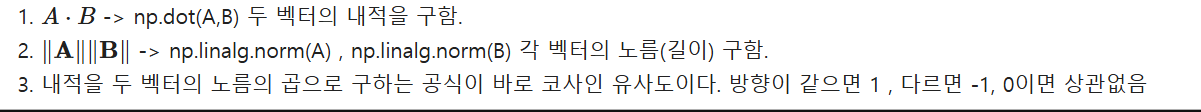</p>

In [42]:
# 행렬 8 x 8 벡터로 연산 64 
d0_vector = digits.images[0].reshape(-1)
d1_vector = digits.images[1].reshape(-1)
d0_vector.shape , d1_vector.shape

((64,), (64,))

In [43]:
# flatten() 
d0_vector = digits.images[0].flatten() # A
d1_vector = digits.images[1].flatten() # B
d0_vector.shape , d1_vector.shape

((64,), (64,))

In [44]:
# 공식적용해서 유사도 구하기
cosine_sim_value = np.dot(d0_vector,d1_vector) / (np.linalg.norm(d0_vector) * np.linalg.norm(d1_vector))

In [45]:
cosine_sim_value

np.float64(0.5191023426414686)

<h1 id="%EC%82%AC%EC%9D%B4%ED%82%B7-%EB%9F%B0%EC%97%90-%EB%8D%B0%EC%9D%B4%ED%84%B0-%EB%A7%A4%EA%B0%9C%EB%B3%80%EC%88%98-%ED%98%95%EC%8B%9D">사이킷 런에 데이터 매개변수 형식¶</h1>
: sklearn.function([vector])

In [46]:
A = np.array([d0_vector])
A.shape , A.ndim

((1, 64), 2)

In [47]:
B = np.array([d1_vector])

In [48]:
# 사이킷런에서 제공해주는 함수 (회사에서 유사도 구할 때 적극 추천)
from sklearn.metrics.pairwise import cosine_similarity
skcosin_sim_val = cosine_similarity(A,B)
skcosin_sim_val , skcosin_sim_val.shape, skcosin_sim_val[0][0]

(array([[0.51910234]]), (1, 1), np.float64(0.5191023426414685))

## 연습 문제
- 다음 코드를 실행하면 MNIST 숫자 이미지 전체 데이터를 모두 벡터로 변환하여 하나의 넘파이 행렬 X를 만든다. 
    이 행렬을 이용하여 다음 문제를 풀어라.

from sklearn.datasets import load_digits

X = load_digits().data

digits = load_digits()

1) * 내적을 이용하여 첫 번째 이미지와 10번째 이미지의 유사도를 구하라.(시각화 포함)
2) * 첫번째 이미지와 유사한 이미지를 찾아서 모두 출력 하시오. 출력시 이미지 인덱스와 유사도를 출력하고 유사도는 상위 10개만 출력하시오
> 유사도를 측정하는 함수(mycosine_similarity) 로 만들어서 테스트 할 것

In [50]:
from sklearn.datasets import load_digits
X = load_digits().data
digits = load_digits()

In [51]:
X.shape

(1797, 64)

In [52]:
#1) * 내적을 이용하여 첫 번째 이미지와 10번째 이미지의 유사도를 구하라.(시각화 포함)
# np.float64(0.7808790331160783)

In [53]:
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

shape => (64,), (64,)


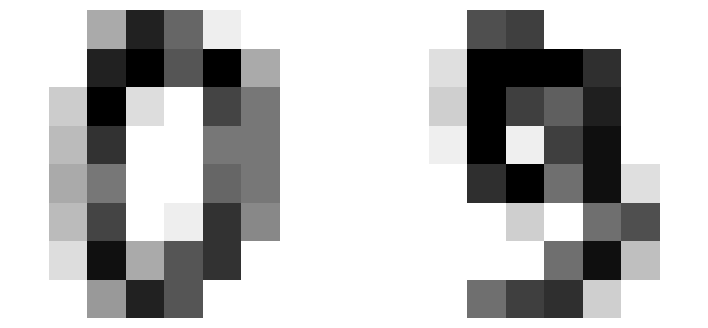

******************************


np.float64(0.7808790331160783)

In [54]:
#0번지 , 9번지 이미지를 벡터로 각각 저장
img1_vector =  X[0]
img9_vector =  X[9]
print(f"shape => {img1_vector.shape}, {img9_vector.shape}")
plt.figure(figsize=(9,4))
listv = [0,9]
for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.imshow(digits.images[listv[i]], cmap=plt.cm.gray_r)
    plt.axis('off')
plt.show()
print("*"*30)
similarity09 = np.dot(img1_vector, img9_vector) / \
                (np.linalg.norm(img1_vector) * np.linalg.norm(img9_vector))
similarity09 #0.7808790331160783

In [55]:
#* 첫번째 이미지와 유사한 이미지를 찾아서 모두 출력 하시오. 출력시 이미지 인덱스와 유사도를 출력하고 유사도는 상위 5개만 출력하시오
#유사도를 측정하는 함수(cosine_similarity) 로 만들어서 테스트 할 것

In [56]:
X = load_digits().data
digits = load_digits()
def mycosine_similarity(A, B):
    return np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

In [57]:
sims = np.array([mycosine_similarity(X[0], img) for img in X])
print(f"0번째 이미지와 유사한 데이터 찾기 => {sims}")

0번째 이미지와 유사한 데이터 찾기 => [1.         0.51910234 0.61684198 ... 0.71121668 0.82580797 0.74430965]


In [58]:
most_sim_index= np.argsort(sims)[::-1][1:]
print(f"유사도가 높은 순으로 정렬(자기 자신은 제외)한 인덱스  => {most_sim_index}")
top_10 = [ (index,sims[index]) for index in most_sim_index[:10]]
print(f"상위 10개 유사한 이미지의 인덱스와 유사도 =>{top_10}")

유사도가 높은 순으로 정렬(자기 자신은 제외)한 인덱스  => [ 877  464 1365 ... 1213 1631 1626]
상위 10개 유사한 이미지의 인덱스와 유사도 =>[(np.int64(877), np.float64(0.9807386373853507)), (np.int64(464), np.float64(0.9744736605756292)), (np.int64(1365), np.float64(0.9741884555651185)), (np.int64(1541), np.float64(0.9718313651280307)), (np.int64(1167), np.float64(0.971130132636595)), (np.int64(1029), np.float64(0.9708584122550116)), (np.int64(396), np.float64(0.9687932204179077)), (np.int64(1697), np.float64(0.966018826643372)), (np.int64(646), np.float64(0.965489736237586)), (np.int64(1342), np.float64(0.9639901017889236))]


In [59]:
aa = np.array([1,3,5,2,10,11])
#높은 순으로 정렬 했을 때 인덱스 반환
aa_index = np.argsort(aa)[::-1]
aa_index

array([5, 4, 2, 1, 3, 0])

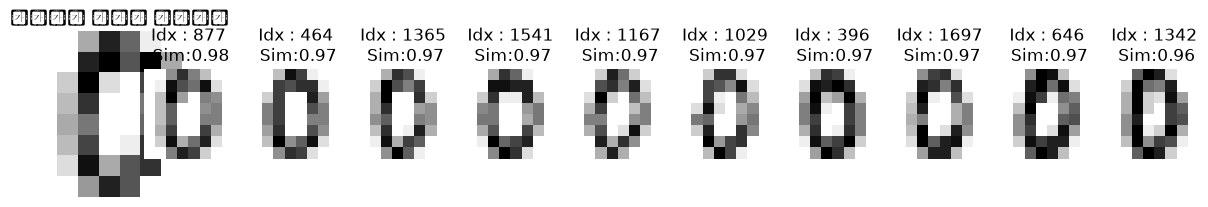

In [65]:
plt.figure(figsize=(15,3))
plt.subplot(1,6,1)
plt.imshow(X[0].reshape(8,8),cmap=plt.cm.gray_r)
plt.axis('off')
plt.title('유사도가 비슷한 이미지들')
for i , (index,sim) in enumerate(top_10,start=1):
    plt.subplot(1,11,i+1)
    plt.imshow(X[index].reshape(8,8),cmap=plt.cm.gray_r)
    plt.title(f'Idx : {index}\n Sim:{sim:.2f}')
    plt.axis('off')
plt.show()

In [66]:
top_10[0] , type(top_10[0])

((np.int64(877), np.float64(0.9807386373853507)), tuple)

In [67]:
np.array(top_10).shape

(10, 2)

In [70]:
import sys
!{sys.executable} -m pip install pandas

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------------- ------------------------- 3.7/9.8 MB 18.1 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.8 MB 22.8 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 18.5 MB/s  0:00:00


In [71]:
import pandas as pd

In [72]:
#유사도가 높은 상위 10개의 데이터 DataFrame으로 변환
df = pd.DataFrame(top_10,columns=['Index','Similarity']).set_index('Index')
df.head(2)

,Similarity
Index,
877,0.980739
464,0.974474


In [73]:
# Map제네레이터 -> Index, 컬럼을 쌍으로 반환
df.itertuples()

In [74]:
list(df.itertuples())[:3]

[Pandas(Index=877, Similarity=0.9807386373853507),
 Pandas(Index=464, Similarity=0.9744736605756292),
 Pandas(Index=1365, Similarity=0.9741884555651185)]

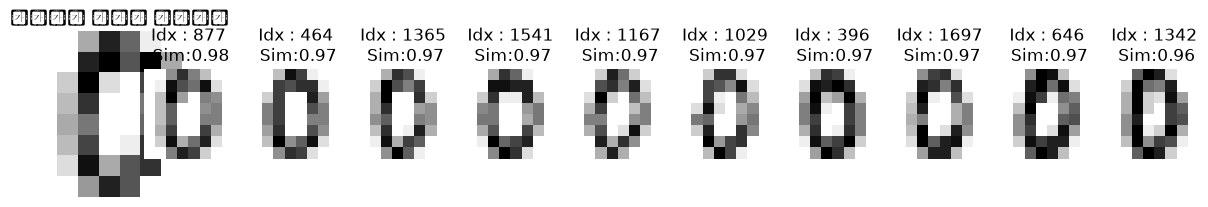

In [77]:
plt.figure(figsize=(15,3))
plt.subplot(1,6,1)
plt.imshow(X[0].reshape(8,8),cmap=plt.cm.gray_r)
plt.axis('off')
plt.title('유사도가 비슷한 이미지들')
for i , row in enumerate(df.itertuples(),start=1):
    plt.subplot(1,11,i+1)
    plt.imshow(X[row.Index].reshape(8,8),cmap=plt.cm.gray_r)
    plt.title(f'Idx : {row.Index}\n Sim:{row.Similarity:.2f}')
    plt.axis('off')
plt.show()

<h2 id="argmax(),argmin()-*****">argmax(),argmin() *****¶</h2>
<p>: 최대값,최소값의 인덱스를 반환 해주는 함수</p>

<p>최대값이 "어디에 있는지" 반환 ,최소값이 "어디에 있는지" 반환</p>

In [78]:
#<개인 연습문제> 다음 행렬의 곱을 출력하시오.
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[1, 2], [3, 4], [5, 6]])
#A와 B를 np.arange(),reshape을 사용해서 위의 A,B의 행렬로 변경 해보기
"""
결과)
array([[22, 28],
       [49, 64]])
"""
A @ B

array([[22, 28],
       [49, 64]])

In [81]:
A = np.arange(1,7).reshape(2,3)
B = np.arange(1,7).reshape(3,2)

In [82]:
print(A.shape , B.shape)
A,B,A@B

(2, 3) (3, 2)


(array([[1, 2, 3],
        [4, 5, 6]]),
 array([[1, 2],
        [3, 4],
        [5, 6]]),
 array([[22, 28],
        [49, 64]]))